In [1]:
# ===============================================================
# 📘 Fake Review Detection - Phase 1 & 2
# Data Analysis + Preprocessing
# ===============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import joblib

%matplotlib inline

df = pd.read_csv("../dataset/reviews_dataset.csv")
print("✅ Dataset Loaded Successfully!")
print("Shape:", df.shape)
df.head()

✅ Dataset Loaded Successfully!
Shape: (1000, 8)


,review_text,category,rating,username,ip_address,post_timestamp,review_timestamp,label
0,I’ve been using it for a week and it’s perform...,Electronics,5,anthonyramos,68.33.141.216,1749414928607,1749415168607,OR
1,The product quality is excellent and exactly a...,Food,4,kathryn58,102.192.163.82,1745562088607,1745564188607,OR
2,Excellent quality very very very good nice and...,Food,4,joebaker,167.205.183.204,1746674488607,1746676888607,CG
3,Very satisfied not fake review trust me genuin...,Electronics,3,nicholas99,134.5.37.208,1755011248607,1755012268607,CG
4,Very satisfied not fake review trust me genuin...,Clothing,3,alicia63,177.21.162.18,1746381688607,1746385168607,CG


In [2]:
df.info()
print("\nNull values per column:\n", df.isnull().sum())
print("\nUnique counts per column:\n", df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       1000 non-null   object
 1   category          1000 non-null   object
 2   rating            1000 non-null   int64 
 3   username          1000 non-null   object
 4   ip_address        1000 non-null   object
 5   post_timestamp    1000 non-null   int64 
 6   review_timestamp  1000 non-null   int64 
 7   label             1000 non-null   object
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Null values per column:
 review_text         0
category            0
rating              0
username            0
ip_address          0
post_timestamp      0
review_timestamp    0
label               0
dtype: int64

Unique counts per column:
 review_text           10
category               7
rating                 5
username             100
ip_address          1000
post_timestamp  

C:\Users\karan\AppData\Local\Temp\ipykernel_7908\2943069456.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, palette="viridis")


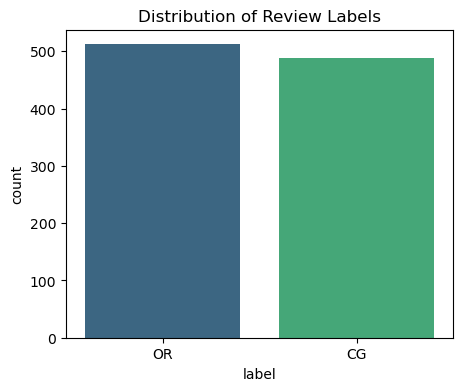

In [3]:
plt.figure(figsize=(5,4))
sns.countplot(x="label", data=df, palette="viridis")
plt.title("Distribution of Review Labels")
plt.show()

In [4]:
df["text_length"] = df["review_text"].apply(len)
df["word_count"] = df["review_text"].apply(lambda x: len(x.split()))
df["time_diff_min"] = (df["review_timestamp"] - df["post_timestamp"]) / (1000 * 60)
df["username_freq"] = df.groupby("username")["username"].transform("count")
df["ip_freq"] = df.groupby("ip_address")["ip_address"].transform("count")
df["category"] = df["category"].astype("category")
df.head()

,review_text,category,rating,username,ip_address,post_timestamp,review_timestamp,label,text_length,word_count,time_diff_min,username_freq,ip_freq
0,I’ve been using it for a week and it’s perform...,Electronics,5,anthonyramos,68.33.141.216,1749414928607,1749415168607,OR,62,12,4.0,9,1
1,The product quality is excellent and exactly a...,Food,4,kathryn58,102.192.163.82,1745562088607,1745564188607,OR,58,9,35.0,14,1
2,Excellent quality very very very good nice and...,Food,4,joebaker,167.205.183.204,1746674488607,1746676888607,CG,63,10,40.0,14,1
3,Very satisfied not fake review trust me genuin...,Electronics,3,nicholas99,134.5.37.208,1755011248607,1755012268607,CG,64,10,17.0,8,1
4,Very satisfied not fake review trust me genuin...,Clothing,3,alicia63,177.21.162.18,1746381688607,1746385168607,CG,64,10,58.0,8,1


In [5]:
numeric_cols = ["rating", "text_length", "word_count", "time_diff_min", "username_freq", "ip_freq"]
df[numeric_cols].describe()

,rating,text_length,word_count,time_diff_min,username_freq,ip_freq
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0
mean,3.040000,55.261000,9.168000,30.199000,11.120000,1.0
std,1.400129,10.606195,2.598948,17.668831,3.427148,0.0
min,1.000000,34.000000,5.000000,1.000000,4.000000,1.0
25%,2.000000,49.000000,7.000000,15.000000,9.000000,1.0
50%,3.000000,58.000000,9.000000,30.000000,11.000000,1.0
75%,4.000000,63.000000,10.000000,46.000000,14.000000,1.0
max,5.000000,72.000000,14.000000,60.000000,20.000000,1.0


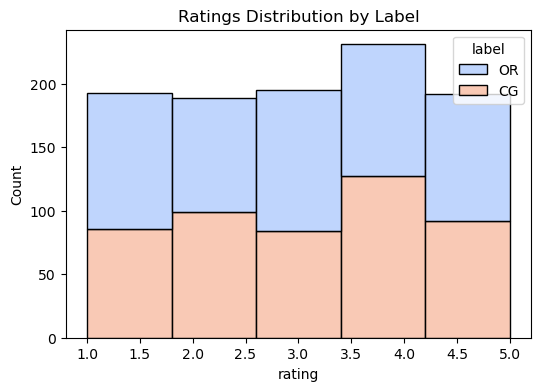

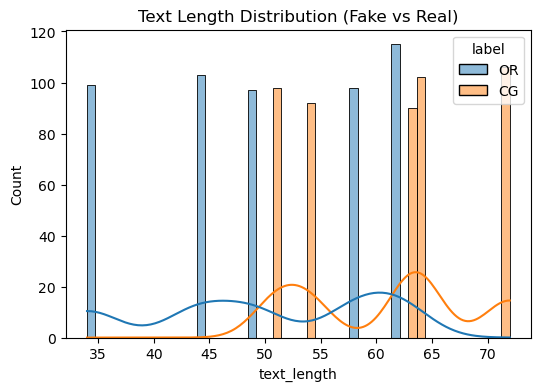

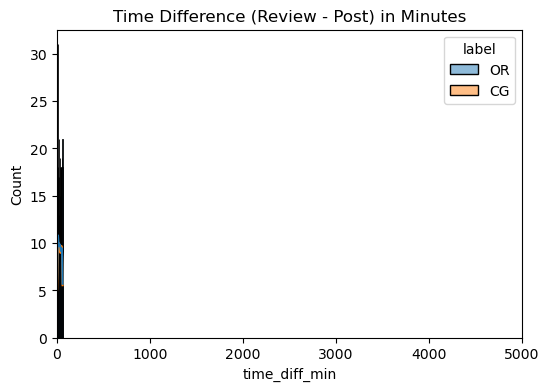

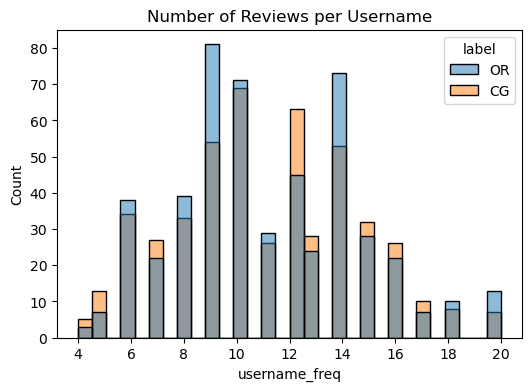

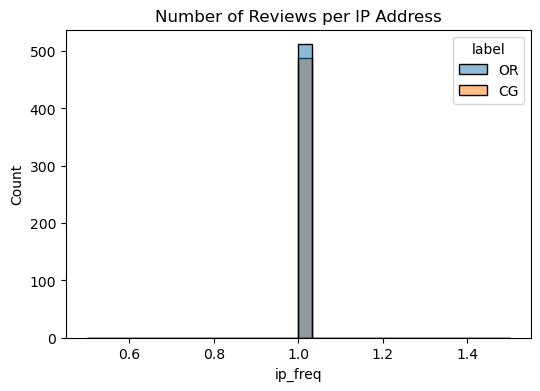

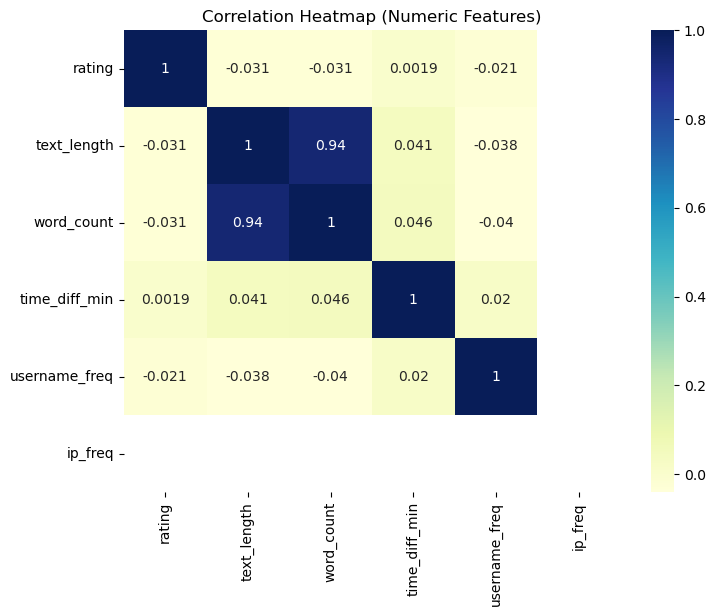

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="rating", hue="label", multiple="stack", bins=5, palette="coolwarm")
plt.title("Ratings Distribution by Label")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data=df, x="text_length", hue="label", bins=50, kde=True)
plt.title("Text Length Distribution (Fake vs Real)")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data=df, x="time_diff_min", hue="label", bins=50, kde=True)
plt.title("Time Difference (Review - Post) in Minutes")
plt.xlim(0, 5000)
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data=df, x="username_freq", hue="label", bins=30)
plt.title("Number of Reviews per Username")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data=df, x="ip_freq", hue="label", bins=30)
plt.title("Number of Reviews per IP Address")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [7]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

df["clean_text"] = df["review_text"].apply(clean_text)
df[["review_text", "clean_text"]].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\karan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review_text,clean_text
0,I’ve been using it for a week and it’s perform...,ive using week performing really well
1,The product quality is excellent and exactly a...,product quality excellent exactly described
2,Excellent quality very very very good nice and...,excellent quality good nice awesome product
3,Very satisfied not fake review trust me genuin...,satisfied fake review trust genuine genuine ge...
4,Very satisfied not fake review trust me genuin...,satisfied fake review trust genuine genuine ge...


In [8]:
tfidf = TfidfVectorizer(max_features=3000)
X_text = tfidf.fit_transform(df["clean_text"]).toarray()
X_num = df[["rating", "text_length", "word_count", "time_diff_min", "username_freq", "ip_freq"]].values
X = np.hstack((X_text, X_num))
y = df["label"].map({"OR": 0, "CG": 1}).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Data Preprocessing Complete!")
print("Train size:", X_train.shape, " Test size:", X_test.shape)

joblib.dump(tfidf, "../app/vectorizer.pkl")
np.savez("../dataset/preprocessed_data.npz", X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)

✅ Data Preprocessing Complete!
Train size: (800, 45)  Test size: (200, 45)


In [9]:
print("✅ Summary:")
print(f"Total Reviews: {len(df)}")
print(f"Genuine (OR): {(df['label'] == 'OR').sum()}")
print(f"Fake (CG): {(df['label'] == 'CG').sum()}")

print("\nKey Observations:")
print("- Fake reviews often have very short text and very small time_diff_min.")
print("- Many fake reviews come from IPs with multiple submissions.")
print("- Genuine reviews show wider variety in rating and text length.")
print("- These engineered features will help Logistic Regression detect patterns effectively.")

✅ Summary:
Total Reviews: 1000
Genuine (OR): 512
Fake (CG): 488

Key Observations:
- Fake reviews often have very short text and very small time_diff_min.
- Many fake reviews come from IPs with multiple submissions.
- Genuine reviews show wider variety in rating and text length.
- These engineered features will help Logistic Regression detect patterns effectively.
